## Neural Prophet library Forecast

For starters we will upload the daily terrestrial data from NEON data base and visualize it to fetch missing data 

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
from neuralprophet import NeuralProphet

# upload data from NEON page for terrestrial daily data
data = pd.read_csv("terrestrial_daily-targets.csv", parse_dates=["datetime"])

We will filter the data to only use Abby Road's net ecosystem exchange data

In [66]:
site = "ABBY" # we'll use only ABBY ROAD site
variable = "nee" # we'll use only Net Ecosystem Exchange data

In [67]:
filtered_data = data[(data["site_id"] == site) & (data["variable"] == variable)].copy()

# turn datetime column to panda date time
filtered_data['datetime'] = pd.to_datetime(filtered_data['datetime']).dt.tz_localize(None) # dont consider timezone
filtered_data = filtered_data.set_index("datetime").asfreq("D") # daily frecuency data

Visualization of Raw data

Text(0, 0.5, 'C02 Flux')

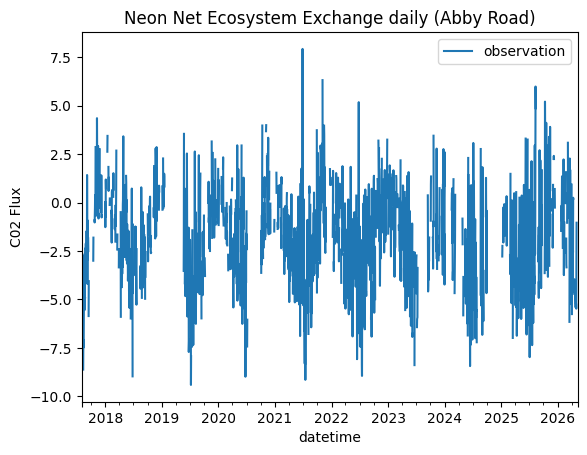

In [68]:
filtered_data.plot()
plt.title("Neon Net Ecosystem Exchange daily (Abby Road)")
plt.ylabel("C02 Flux")

As we can see, there are missing data for certain datetimes, so we will fit the data by using linear interpolation

In [74]:
filtered_data["observation"] = filtered_data["observation"].interpolate(method="linear")
filtered_data = filtered_data.reset_index() 

# check the maximum of our data
filtered_data["datetime"].max()

Timestamp('2026-05-10 00:00:00')

For neural prophet model we need the datetime column taged as `ds` and the observation column as `y`

In [75]:
df = filtered_data[['datetime', 'observation']].rename(columns={'datetime': 'ds', 'observation': 'y'})

Now we will separate the data before 2026 as the training data for the model and predict all 2026 up until `may 10th`

In [76]:
df_train = df[df['ds'] < "2026-01-01"].copy() # take the training dates as evertyhing before 2026
df_test = df[df['ds'] >= "2026-01-01"].copy() # test prediction for all 2026 

Now let's start the `neural prophet` model

WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - C:\Users\user\miniconda3\envs\entorno_darts\lib\site-packages\neuralprophet\df_utils.py:464: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  if df.groupby("ID").apply(lambda x: x.duplicated("ds").any()).any():

WARNING - (py.warnings._showwarnmsg) - C:\Users\user\miniconda3\envs\entorno_darts\lib\site-packages\neuralprophet\df_utils.py:

Training: |                                                                                      | 0/? [00:00<…

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (48) is too small than the required number                     for the learning rate finder (237). The results might not be optimal.


Finding best initial lr:   0%|          | 0/237 [00:00<?, ?it/s]

Training: |                                                                                      | 0/? [00:00<…

WARNING - (py.warnings._showwarnmsg) - C:\Users\user\miniconda3\envs\entorno_darts\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.967% of the data.
WARNING - (py.warnings._showwarnmsg) - C:\Users\user\miniconda3\envs\entorno_darts\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - C:\Users\user\miniconda3\envs\entorno_darts\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``ast

Predicting: |                                                                                    | 0/? [00:00<…

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.
WARNING - (py.warnings._showwarnmsg) - C:\Users\user\miniconda3\envs\entorno_darts\lib\site-packages\neuralprophet\plot_forecast_matplotlib.py:84: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ds = fcst["ds"].dt.to_pydatetime()



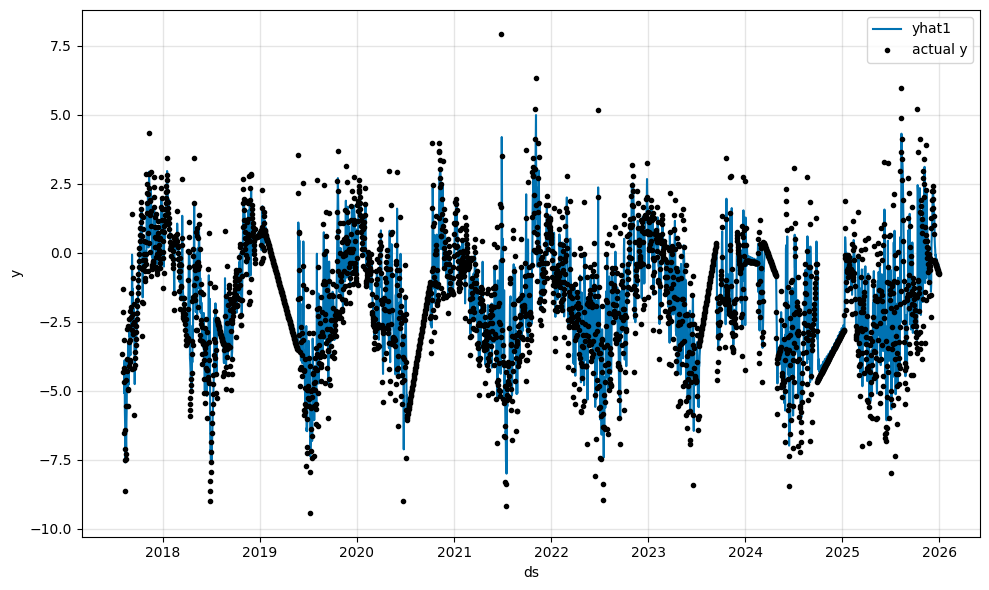

In [81]:
# Start the model
m = NeuralProphet(
    n_changepoints=0,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    n_lags=40,
    n_forecasts=1
)

# Set plotting style with matplotlib
m.set_plotting_backend("matplotlib")

# fit the data 
metrics = m.fit(df_train, freq = "D")

# create blank dataframe for predicting all 2026 till may 5th (125 days)
future = m.make_future_dataframe(df_train,n_historic_predictions=True, periods=125)

# create forecast
forecast = m.predict(future)
m.plot(forecast)

Visualization of the prediction compared to NEON data

WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.
WARNING - (py.warnings._showwarnmsg) - C:\Users\user\miniconda3\envs\entorno_darts\lib\site-packages\neuralprophet\plot_forecast_matplotlib.py:84: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ds = fcst["ds"].dt.to_pydatetime()



2026-01-01 00:00:00


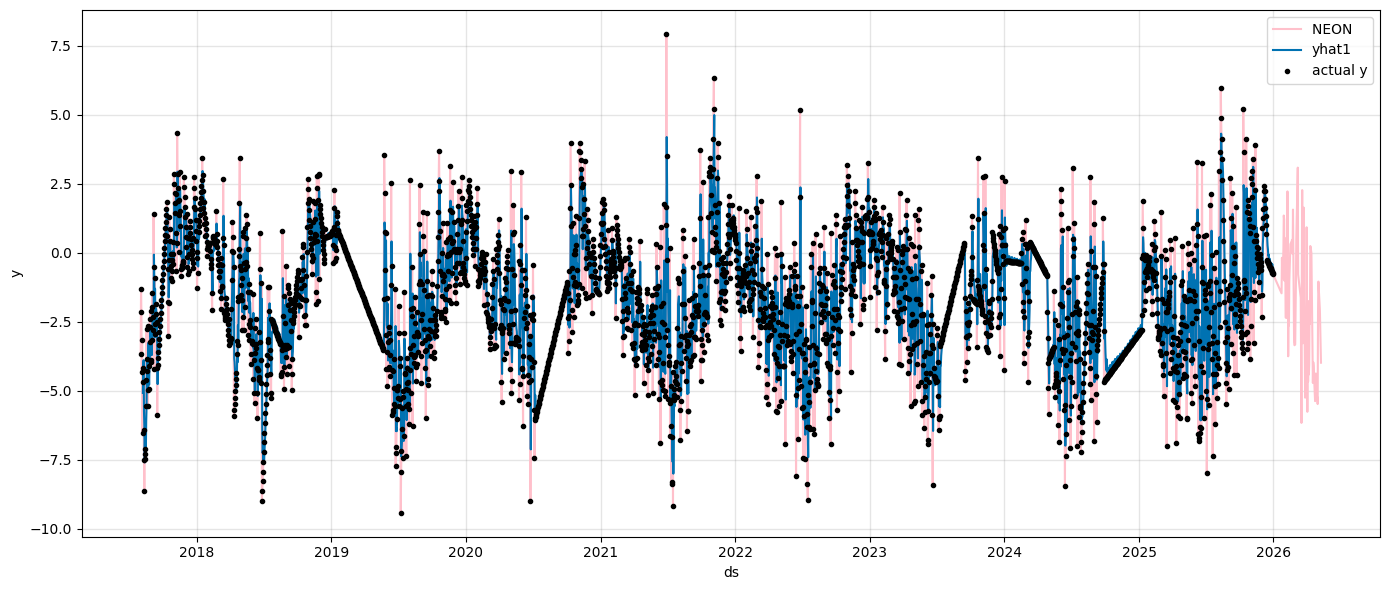

In [82]:
# start figure
fig, ax = plt.subplots(figsize=(14, 6))

# plot NEON data
ax.plot(df['ds'],df['y'], color = "pink", label = "NEON ")

# plot forecast
m.plot(forecast,xlabel="ds",ylabel="y",ax = ax,figsize=(10, 6))

print(forecast['ds'].max())

Let's make a zoom in in the forecast section (2026)

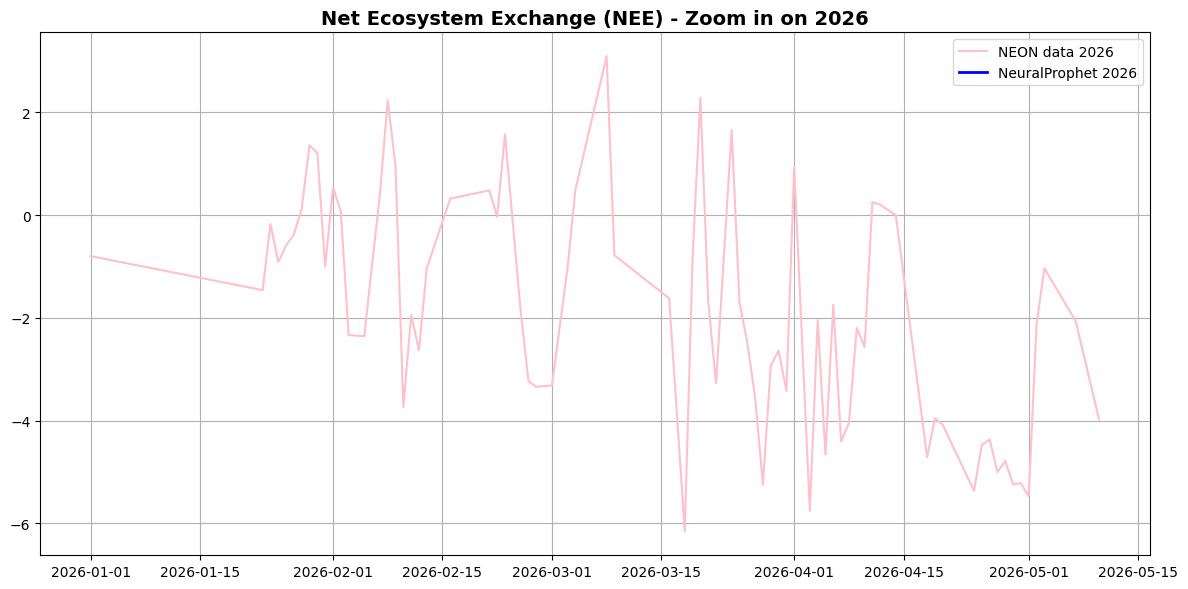

In [104]:
# start mathplot figure
fig, ax = plt.subplots(figsize=(12, 6))

# plot real data of all 2026
ax.plot(df_test['ds'], df_test['y'], label="NEON data 2026", color="pink")

# plot forecast for 2026
forecast_2026 = forecast[forecast['ds'] >= "2026-01-01"]
ax.plot(forecast_2026['ds'], forecast_2026['yhat1'], label="NeuralProphet 2026", color="blue", lw=2)

# set title
ax.set_title("Net Ecosystem Exchange (NEE) - Zoom in on 2026", fontsize=14, fontweight="bold")
ax.grid(True) # create grid

# show plot
plt.tight_layout()
plt.legend()
plt.show()

Now we will analize the components of the forecast such as tendency, seasonal periodicity and others...

WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.
WARNING - (py.warnings._showwarnmsg) - C:\Users\user\miniconda3\envs\entorno_darts\lib\site-packages\neuralprophet\plot_forecast_matplotlib.py:300: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  fcst_t = fcst["ds"].dt.to_pydatetime()

WARNING - (py.warnings._showwarnmsg) - C:\Users\user\miniconda3\envs\entorno_darts\lib\site-packages\neuralprophet\plot_forecast_matplotlib.py:392: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavio

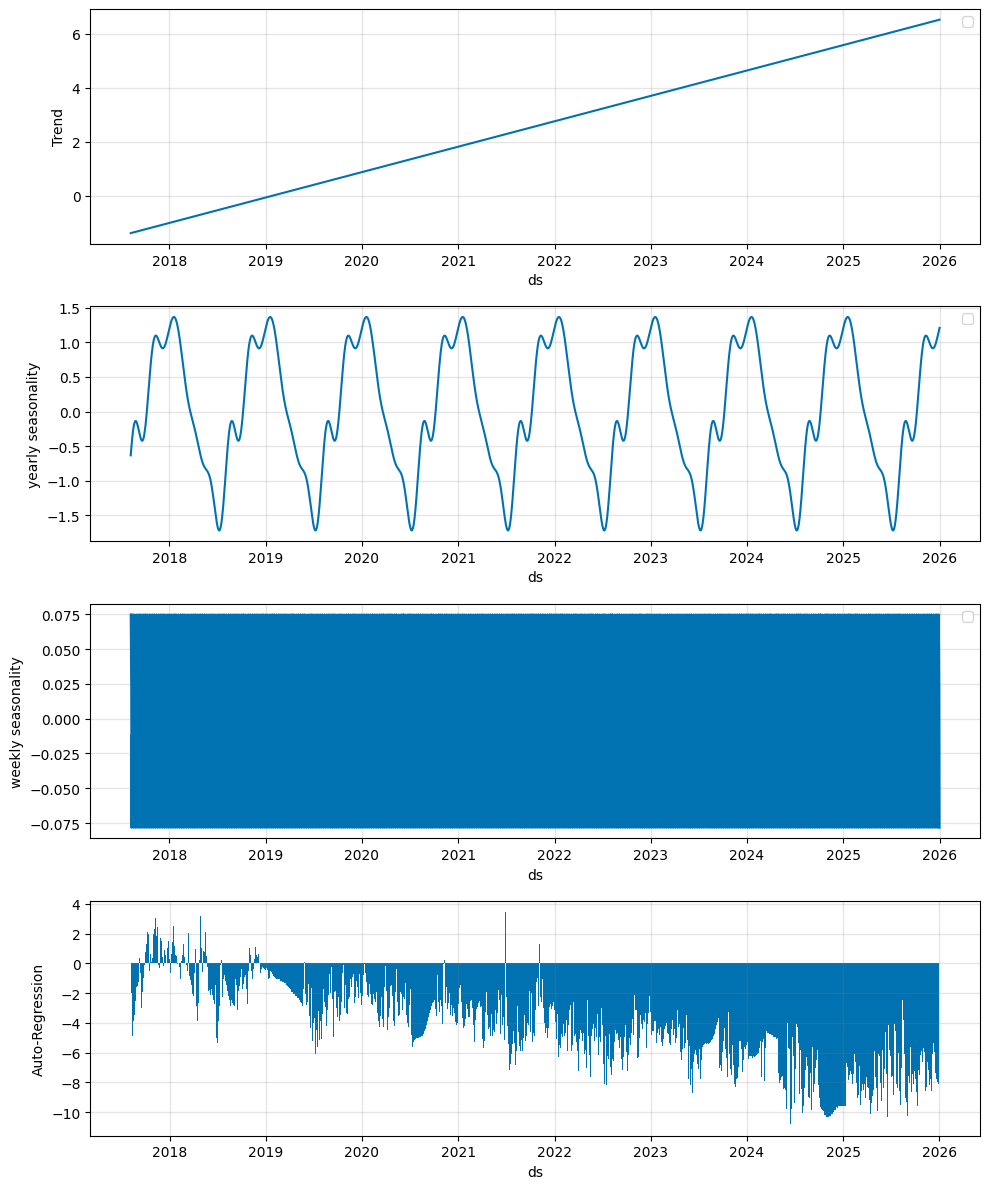

In [105]:
m.plot_components(forecast)

Now we will analize the parameters of the forecast such as tendency, seasonal periodicity and others...

WARNING - (py.warnings._showwarnmsg) - C:\Users\user\miniconda3\envs\entorno_darts\lib\site-packages\neuralprophet\df_utils.py:464: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  if df.groupby("ID").apply(lambda x: x.duplicated("ds").any()).any():

WARNING - (py.warnings._showwarnmsg) - C:\Users\user\miniconda3\envs\entorno_darts\lib\site-packages\neuralprophet\plot_model_parameters_plotly.py:237: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  x=df_y["ds"].dt.to_pydatetime(),

WARNING - (py.warnings._showwarnm

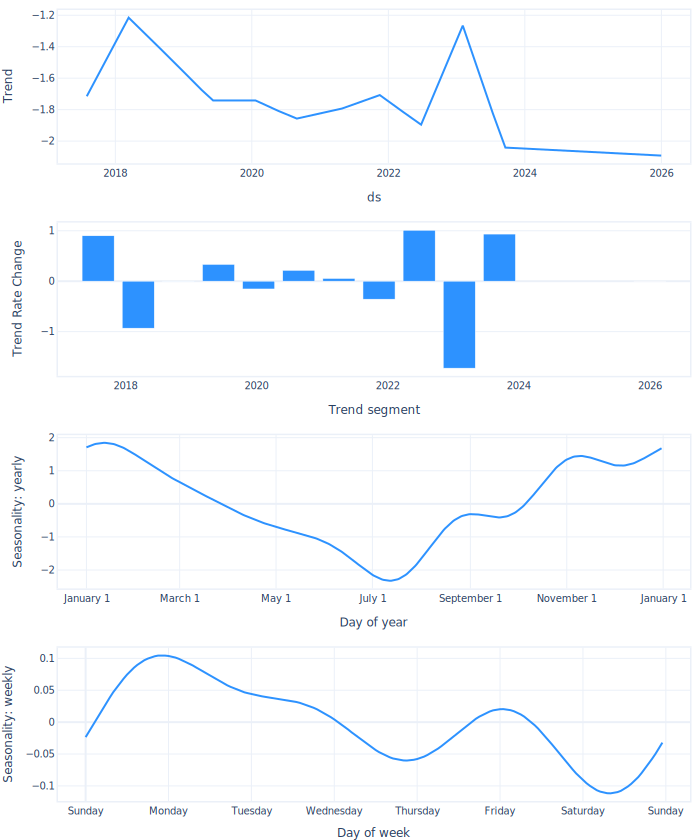

In [112]:
m.set_plotting_backend("plotly-static")
m.plot_parameters()

## Uncertainty

In [107]:
confidence_level = 0.9

boundaries = round((1 - confidence_level) / 2, 2)
# NeuralProphet only accepts quantiles value in between 0 and 1
quantiles = [boundaries, confidence_level + boundaries]

WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - C:\Users\user\miniconda3\envs\entorno_darts\lib\site-packages\neuralprophet\df_utils.py:464: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  if df.groupby("ID").apply(lambda x: x.duplicated("ds").any()).any():

WARNING - (py.warnings._showwarnmsg) - C:\Users\user\miniconda3\envs\entorno_darts\lib\site-packages\neuralprophet\df_utils.py:

Training: |                                                                                      | 0/? [00:00<…

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (49) is too small than the required number                     for the learning rate finder (237). The results might not be optimal.


Finding best initial lr:   0%|          | 0/237 [00:00<?, ?it/s]

Training: |                                                                                      | 0/? [00:00<…

WARNING - (py.warnings._showwarnmsg) - C:\Users\user\miniconda3\envs\entorno_darts\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.967% of the data.
WARNING - (py.warnings._showwarnmsg) - C:\Users\user\miniconda3\envs\entorno_darts\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - C:\Users\user\miniconda3\envs\entorno_darts\lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``ast

Predicting: |                                                                                    | 0/? [00:00<…

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column
WARNING - (NP.plotting.log_warning_deprecation_plotly) - DeprecationWarning: default plotting_backend will be changed to plotly in a future version. Switch to plotly by calling `m.set_plotting_backend('plotly')`.
WARNING - (py.warnings._showwarnmsg) - C:\Users\user\miniconda3\envs\entorno_darts\lib\site-packages\neuralprophet\plot_forecast_matplotlib.py:84: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ds = fcst["ds"].dt.to_pydatetime()



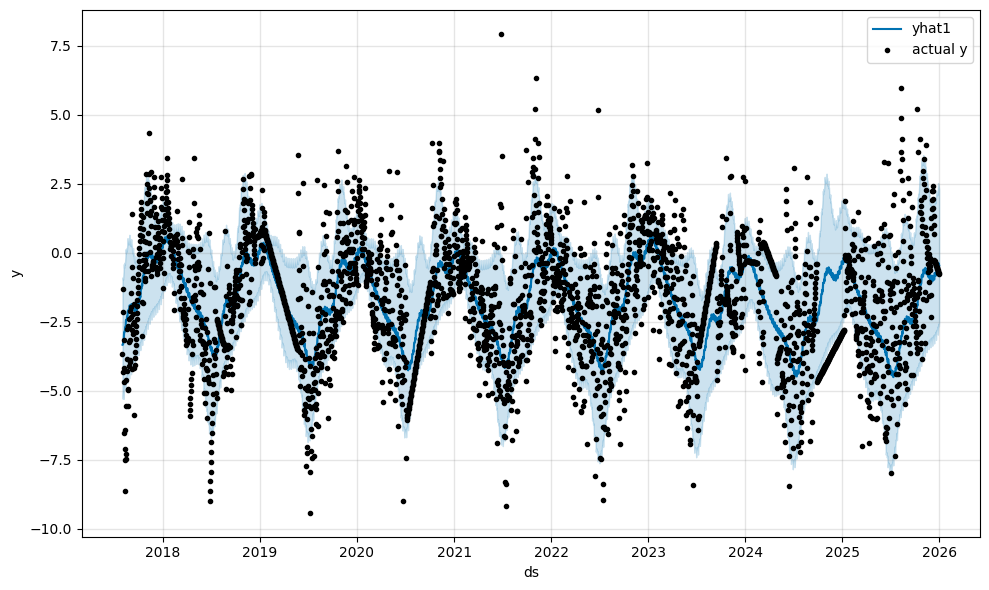

In [110]:
# Create NeuralProphet model with list of quantiles
m = NeuralProphet(quantiles=quantiles)

# set back to matplotlib and plot
m.set_plotting_backend("matplotlib")
m.plot(forecast)